# Расчёт метрик сервиса доставки еды.

## Описание данных

## Таблица `analytics_events`

В таблице хранятся данные о событиях в период с 30.04.2021 по 02.07.2021. Поля таблицы:

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `visitor_uuid`         | идентификатор посетителя. Это идентификатор, который система присваивает любому новому пользователю независимо от того, регистрировался ли он в продукте.        |
| `user_id` | идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.                |
| `device_type`             | тип платформы, с которой посетитель зашёл в продукт.                          |
| `city_id`          | город, из которого посетитель зашёл в сервис.                                |
| `age`          | возрастная группа пользователя.                                        |
| `source`     | рекламный источник привлечения посетителя.                             |
| `first_date`   | дата первого посещения продукта.                            |
| `visit_id`     | уникальный идентификатор сессии.|
| `event`     | название аналитического события (`main_page`, `authorization`, `rest_page`, `object_page`, `order`). |
| `datetime`     | дата и время события.|
| `log_date`     | дата события.|
| `rest_id`     | никальный идентификатор сети, к которой принадлежит ресторан. Заполняется для заказов, карточек ресторанов и блюд.|
| `object_id`     | уникальный идентификатор блюда. Заполняется для заказов и карточек блюд.|
| `listing_id`     | уникальный идентификатор блюда в листинге. Листингом называется набор блюд, которые система рекомендует пользователю при просмотре страницы ресторана. Заполняется только для событий `rest_page`.|
| `position`     |  позиция блюда в листинге. Чем меньше номер, тем ближе блюдо к началу страницы. Заполняется только для событий `rest_page`.|
| `order_id`     | уникальный идентификатор заказа.|
| `revenue`     |  выручка от заказа в рублях. Это та сумма, которую пользователь видит при оплате.|
| `delivery`     | стоимость доставки в рублях.|
| `commission`     | комиссия, которую сервис берёт с выручки ресторана.|

---

## Таблица `advertisement_budgets`

В таблице хранятся данные о ежедневных затратах на рекламу. Поля таблицы:

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `source`         | рекламный источник.         |
| `date` | дата рекламных затрат.                |
| `budget`             | дневной бюджет в рублях.                          |

---


## Таблица `partners`

Это справочник партнёрских сетей и их ресторанов. Поля таблицы:

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `rest_id`         | уникальный идентификатор сети, к которой принадлежит ресторан (одна сеть может быть представлена в нескольких городах).         |
| `chain` | название сети, к которой принадлежит ресторан.                |
| `type`             | тип кухни.                          |
| `city_id`          | город, в котором находится ресторан.                                |
| `commission`          | комиссия в процентах, которую сервис берёт с выручки ресторана.                                        |

---

## Таблица `dishes`

Это справочник блюд, доступных в партнёрских ресторанах. Поля таблицы:

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `object_id`         | уникальный идентификатор блюда.         |
| `name` | название блюда.                |
| `spicy`             | логический признак острых блюд. 1 — блюдо острое.                          |
| `fish`          | логический признак рыбных блюд. 1 — блюдо содержит морепродукты.                                |
| `meat`          | логический признак мясных блюд. 1 — блюдо содержит мясо.                                       |
| `rest_id`     |  уникальный идентификатор ресторана, из которого можно заказать блюдо.                             |

---

## Таблица `cities`

Справочник населённых пунктов, в которых можно пользоваться продуктом. Поля таблицы:

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `city_id`         | уникальный идентификатор населённого пункта.         |
| `city_name` | название населённого пункта.                |


In [1]:
!pip install duckdb pandas

In [2]:
import duckdb
import pandas as pd

In [3]:
# Выполняем SQL‑запрос прямо к CSV‑файлу
cities = duckdb.sql("""
    SELECT *
    FROM read_csv_auto('cities.csv')
""").df()

cities = cities.reset_index(drop=True)

# Выводим результат
print(cities.to_string(index=False))

 city_id       city_name
       1          Москва
       2 Санкт-Петербург
       3    Екатеринбург
       4          Казань
       5 Нижний Новгород
       6         Саранск


In [4]:
# Выполняем SQL‑запрос прямо к CSV‑файлу
dishes = duckdb.sql("""
    SELECT *
    FROM read_csv_auto('dishes.csv')
""").df()

dishes = dishes.reset_index(drop=True)

# Выводим результат
print(dishes.to_string(index=False))

 object_id                     name  spicy  fish  meat  rest_id
      1001       Ролл «Филадельфия»      0     1     0      101
      1002                Чизбургер      0     0     1      102
      1003        Пицца «Маргарита»      0     0     0      103
      1004        Шашлык из свинины      1     0     1      104
      1005 Салат «Цезарь» с курицей      0     0     1      102
      1006               Суп «Мисо»      0     1     0      101
      1007  Поза (мордовское блюдо)      1     0     1      106
      1008            Каша «Пшёнка»      0     0     0      106
      1009                 Капучино      0     0     0      107
      1010     Круассан с шоколадом      0     0     0      107


In [5]:
# Выполняем SQL‑запрос прямо к CSV‑файлу
partners = duckdb.sql("""
    SELECT *
    FROM read_csv_auto('partners.csv')
""").df()

partners = partners.reset_index(drop=True)

# Выводим результат
print(partners.to_string(index=False))

 rest_id             chain           type  city_id commission
     101         СушиВесла       Японская        1        20%
     102        БургерКинг        Фастфуд        1        15%
     103      ПиццаФабрика    Итальянская        2        18%
     104     ШашлычныйДвор     Кавказская        3        22%
     105 ВегетарианскийРай Вегетарианская        4        17%
     106   МордовскаяКухня   Национальная        6        16%
     107      КофейняУДома           Кафе        6        14%


In [6]:
# Выполняем SQL‑запрос прямо к CSV‑файлу
advert_budgets = duckdb.sql("""
    SELECT *
    FROM read_csv_auto('advertisement_budgets.csv')
""").df()

advert_budgets = advert_budgets.reset_index(drop=True)

# Выводим результат
print(advert_budgets.to_string(index=False))

             source       date  budget
      Яндекс.Директ 2021-05-01    5000
         Google Ads 2021-05-01    4500
          ВКонтакте 2021-05-01    3000
      Яндекс.Директ 2021-05-02    5200
         Google Ads 2021-05-02    4700
ВКонтакте (Саранск) 2021-05-01    1500
ВКонтакте (Саранск) 2021-05-02    1600


In [7]:
# Читаем CSV через pandas 
df = pd.read_csv('analytics_events.csv', encoding='utf-8')

# Регистрируем DataFrame в DuckDB для SQL‑запросов
duckdb.register('analytics_events', df)

# Теперь можно выполнять SQL‑запросы к таблице analytics_events
result = duckdb.sql('SELECT * FROM analytics_events LIMIT 5').df()
print(result.to_string(index=False))

visitor_uuid  user_id device_type  city_id   age        source first_date visit_id         event            datetime   log_date  rest_id  object_id  listing_id  position order_id  revenue  delivery  commission
      abc123    555.0     Android        1 25–34 Яндекс.Директ 2021-05-01    v1001     main_page 2021-05-01 12:05:30 2021-05-01      NaN        NaN         NaN       NaN     None      NaN       NaN         NaN
      abc123    555.0     Android        1 25–34 Яндекс.Директ 2021-05-01    v1001     rest_page 2021-05-01 12:06:15 2021-05-01    101.0        NaN      1001.0       1.0     None      NaN       NaN         NaN
      abc123    555.0     Android        1 25–34 Яндекс.Директ 2021-05-01    v1001   object_page 2021-05-01 12:07:00 2021-05-01    101.0     1001.0         NaN       NaN     None      NaN       NaN         NaN
      xyz789      NaN         iOS        2 35–44     ВКонтакте 2021-05-02    v1002     main_page 2021-05-02 19:30:10 2021-05-02      NaN        NaN         NaN 

## Задача: подготовить QL-запросы в DataLens для визуализации следующих метрик.

- DAU (от англ. daily active users) — количество активных пользователей за день.
- Conversion Rate — коэффициент конверсии.
- Средний чек — средняя сумма покупки на пользователя.
- LTV (от англ. lifetime value) — совокупная ценность клиента за период.
- Retention Rate — коэффициент удержания пользователей.

### Задача 1. Расчёт DAU
Первая задача — расчёт DAU. Рассчитать ежедневное количество активных зарегистрированных клиентов (user_id) за май и июнь 2021 года в городе Саранске. Критерием активности клиента считается размещение заказа. Это позволит оценить эффективность вовлечения клиентов в ключевую бизнес-цель — совершение покупки.

In [8]:
result = duckdb.sql("""
    SELECT
        ae.log_date,
        COUNT(DISTINCT ae.user_id) AS DAU
    FROM analytics_events AS ae
    JOIN cities AS c ON ae.city_id = c.city_id
    WHERE
        ae.log_date BETWEEN '2021-05-01' AND '2021-06-30'
        AND c.city_name = 'Саранск'
        AND ae.order_id IS NOT NULL
    GROUP BY ae.log_date
    ORDER BY ae.log_date ASC
    LIMIT 10
""").df()

Вид графика активности пользователей за день (DAU) в DataLens.

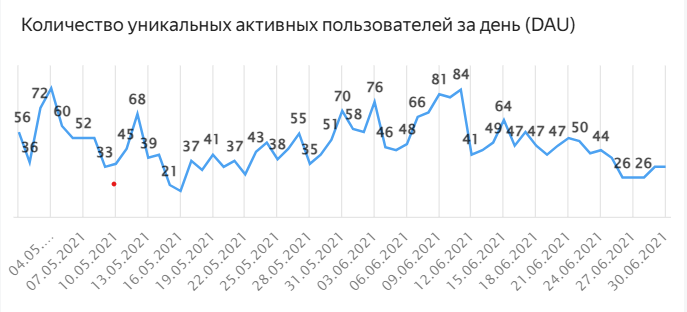

Вывод: Количество уникальных активных пользователей за май и июнь 2021 года в городе Саранске за день (DAU) колеблется в диапазоне от 21 (15.05.2021) до 84 (11.06.2021) человек. 
В среднем количество активных пользователей в первой половине мая меньше, чем в первой половине июня. 
Заметно два периода спада во второй половине мая (до 21 человека/день) и во второй половине июня (до 26 человек/день), где метрика ниже среднего за рассматриваемый период. Кроме того, если изучить метрику детальнее, то можно увидеть спад в выходные дни. Всё это важные сигналы, означающие, что метрику нужно стабилизировать.  
Вероятно влияние сезонности - праздничные дни в мае и июне, конкуренты, маркетинговая активность.

### Задача 2. Расчёт Conversion Rate
Определить активность аудитории: как часто зарегистрированные пользователи переходят к размещению заказа, будет ли одинаковым этот показатель по дням или видны сезонные колебания в поведении пользователей. Для решения этой задачи необходимо рассчитать конверсию зарегистрированных пользователей, которые посещают приложение, в активных клиентов. Критерий активности — размещение заказа. Конверсия должна быть рассчитана за каждый день в мае и июне 2021 года для клиентов из Саранска.

In [9]:
result = duckdb.sql("""
    SELECT 
        ae.log_date,
        ROUND (COUNT (DISTINCT ae.user_id) filter (WHERE ae.order_id IS NOT NULL) / COUNT (DISTINCT ae.user_id)::numeric, 2) AS CR
    FROM analytics_events AS ae
    JOIN cities AS c ON ae.city_id=c.city_id
    WHERE 
        ae.log_date BETWEEN '2021-05-01' AND '2021-06-30' 
        AND c.city_name='Саранск'
    GROUP BY ae.log_date
    ORDER BY ae.log_date ASC
    LIMIT 10
""").df()

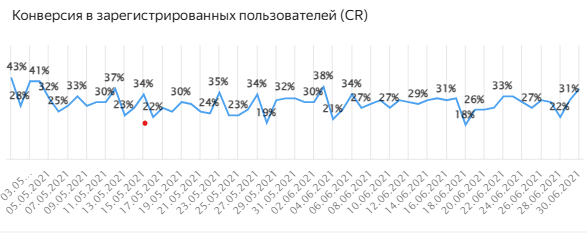

Вывод: Конверсия зарегистрированных пользователей в активных клиентов (тех, кто разместил заказ) за май и июнь 2021 года в городе Саранске колеблется в диапазоне от 18% (18.06.2021) до 43%(01.05.2021). 
Преобладания явных трендов на повышение или понижение не наблюдается. 
Возможные причины колебаний — акции, рекламные кампании или праздники. 

### Задача 3. Расчёт среднего чека
Рассчитать средний чек активных клиентов в Саранске в мае и в июне 2021 года.

In [10]:
result = duckdb.sql("""
WITH orders AS (
    SELECT
        *,
        revenue * commission AS commission_revenue
    FROM analytics_events
    JOIN cities ON analytics_events.city_id = cities.city_id
    WHERE revenue IS NOT NULL
        AND log_date BETWEEN '2021-05-01' AND '2021-06-30'
        AND city_name = 'Саранск'
)

SELECT
    DATE_TRUNC('month', CAST(log_date AS DATE)) AS "Месяц",
    COUNT(DISTINCT order_id) AS "Количество заказов",
    ROUND(SUM(commission_revenue), 2) AS "Сумма комиссии",
    ROUND(SUM(commission_revenue) / COUNT(DISTINCT order_id), 2) AS "Средний чек"
FROM orders
GROUP BY DATE_TRUNC('month', CAST(log_date AS DATE))
ORDER BY DATE_TRUNC('month', CAST(log_date AS DATE)) ASC
""").df()

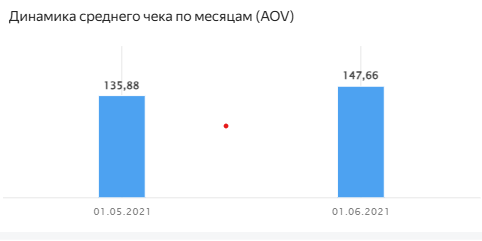

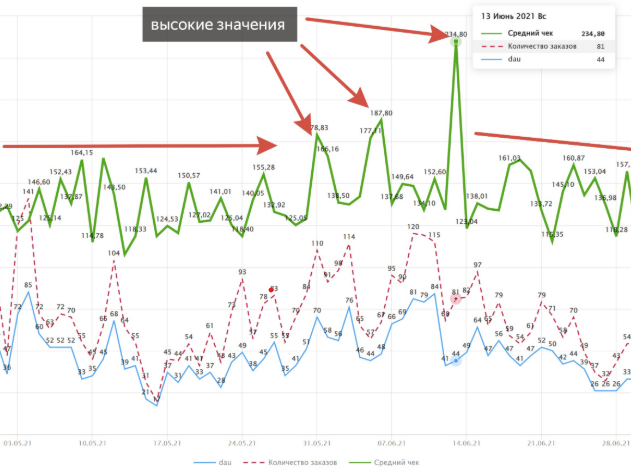

Вывод:Средний чек активных клиентов в городе Саранске в мае и в июне 2021 года составил 135,88 единиц и 147,66 единиц соответственно. Если детальнее рассмотреть средний чек, то он не вырос. Похоже, что была акция, которая сработала только в короткосрочном периоде и далее чек вернулся к средним значениям.
Стоит отметить, что количество заказов выросло – с 2111 в мае до 2225 в июне, сумма комиссии также возросла с 286852.27 единиц до 328539.11 единиц. Особенно показательна ситуация в июне — несмотря на снижение DAU, количество заказов выросло, что может свидетельствовать о повышении числа повторных заказов.

### Задача 4. Расчёт LTV ресторанов
Определить три ресторана из Саранска с наибольшим LTV с начала мая до конца июня. В рамках этой задачи LTV считается как суммарная комиссия, которая была получена от заказов в ресторане за эти два месяца.

In [11]:
result = duckdb.sql("""
WITH orders AS (
    SELECT
        analytics_events.rest_id,
        analytics_events.city_id,
        revenue * commission AS commission_revenue
    FROM analytics_events
    JOIN cities ON analytics_events.city_id = cities.city_id
    WHERE revenue IS NOT NULL
        AND CAST(log_date AS DATE) BETWEEN '2021-05-01' AND '2021-06-30'
        AND city_name = 'Саранск'
)

SELECT
    o.rest_id AS rest_id,
    p.chain AS "Название сети",
    p.type AS "Тип кухни",
    ROUND(SUM(commission_revenue), 2) AS LTV
FROM orders AS o
JOIN partners AS p ON o.rest_id = p.rest_id AND o.city_id = p.city_id
GROUP BY o.rest_id, p.chain, p.type
ORDER BY LTV DESC
LIMIT 3
""").df()

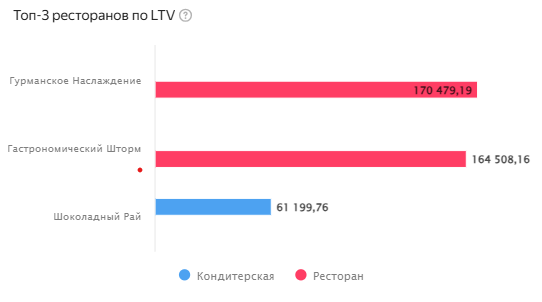

Вывод: В топ-3 ресторанов из Саранска с наибольшим LTV с начала мая до конца июня 2021 года вошли: «Гурманское наслаждение» (суммарный LTV около 170 480 рублей за два месяца), «Гастрономический шторм» (суммарный LTV около 164 509 рублей за два месяца) и «Шоколадный рай» (суммарный LTV около 61 200 рублей за два месяца), при этом первые два заведения это рестораны, а третье – кондитерская. 
Стоит отметить значительный разрыв между 2-м и 3-м местом. Это может говорить как о меньшей популярности кондитерских изделий, так и о разнице в средней стоимости чека или частоте повторных заказов.

### Задача 5. Расчёт LTV ресторанов — самые популярные блюда
Необходимо проанализировать данные о ресторанах и их блюдах, чтобы определить вклад самых популярных блюд из двух ресторанов Саранска — «Гурманское Наслаждение» и «Гастрономический Шторм» — в общий показатель LTV. Для этого будет выбрано пять блюд с максимальным LTV за весь рассматриваемый период, то есть за май — июнь, из этих двух ресторанов.

In [12]:
result = duckdb.sql("""
WITH orders AS (
    SELECT
        analytics_events.rest_id,
        analytics_events.city_id,
        analytics_events.object_id,
        revenue * commission AS commission_revenue
    FROM analytics_events
    JOIN cities ON analytics_events.city_id = cities.city_id
    WHERE revenue IS NOT NULL
        AND CAST(log_date AS DATE) BETWEEN '2021-05-01' AND '2021-06-30'
        AND city_name = 'Саранск'
),

-- Рассчитываем два ресторана с наибольшим LTV
top_ltv_restaurants AS (
    SELECT
        orders.rest_id,
        partners.chain,
        partners.type,
        ROUND(SUM(commission_revenue), 2) AS LTV
    FROM orders
    JOIN partners ON orders.rest_id = partners.rest_id AND orders.city_id = partners.city_id
    GROUP BY orders.rest_id, partners.chain, partners.type
    ORDER BY LTV DESC
    LIMIT 2
)

SELECT
    t.chain AS "Название сети",
    d.name AS "Название блюда",
    d.spicy,
    d.fish,
    d.meat,
    ROUND(SUM(o.commission_revenue), 2) AS LTV
FROM dishes AS d
JOIN top_ltv_restaurants AS t ON t.rest_id = d.rest_id
JOIN orders AS o ON d.object_id = o.object_id
GROUP BY t.chain, d.name, d.spicy, d.fish, d.meat
ORDER BY LTV DESC
LIMIT 5
""").df()

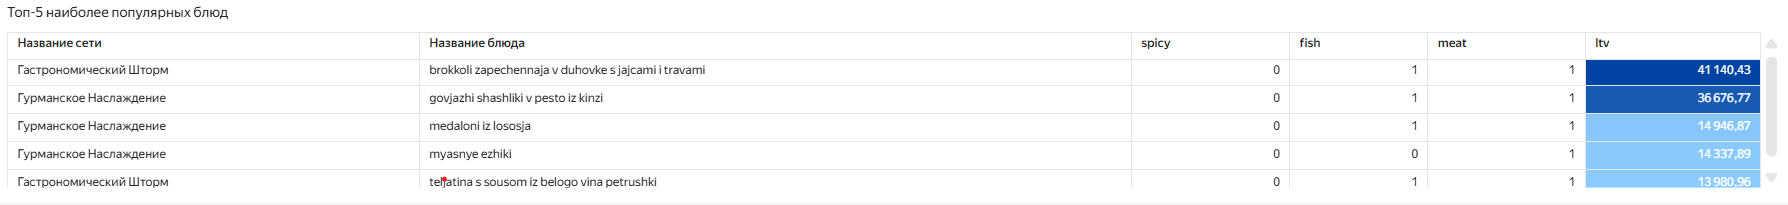

Вывод: В топ-5 наиболее популярных блюд (с максимальным LTV) в первых двух ресторанах «Гурманское наслаждение» и «Гастрономический шторм» вошли неострые блюда преимущественно с мясом в составе, такие как «брокколи запечённая в духовке с яйцами и травами» (суммарный LTV 41 140 рублей), «говяжьи шашлыки в песто из кинзы» (суммарный LTV 36 677 рублей), «медальоны из лосося» (суммарный LTV 14 947 рублей), «мясные ежики» (суммарный LTV 14 338 рублей), «телятина с соусом из белого вина петрушки» (суммарный LTV 13 981 рублей).
Стоит отметить, что эти блюда относятся к премиальному сегменту, что объясняет высокий средний чек и повышает общий вклад в LTV.
Если рассмотреть детальнее, то можно обратить внимание на несоответствие названия и состава блюд (например, "Брокколи, запеченная в духовке, с яйцами и травами", отмечена в категории "мясо и рыба"). 

### Задача 6. Расчёт Retention Rate
Определить показатель возвращаемости: какой процент пользователей возвращается в приложение в течение первой недели после регистрации и в какие дни. Рассчитайте показатель Retention Rate в первую неделю для всех новых пользователей в Саранске.

Данные в проекте анализируются за май и июнь, поэтому для корректного расчёта недельного Retention Rate нужно, чтобы с момента первого посещения прошла хотя бы неделя. В этой связи дата первого посещения продукта будет выбрана в промежутке с начала мая по 24 июня. Retention Rate будет рассчитан по любой активности пользователей, а не только по факту размещения заказа.

In [13]:
result = duckdb.sql("""
WITH new_users AS (
    SELECT DISTINCT
        CAST(first_date AS DATE) AS first_date,
        user_id
    FROM analytics_events
    JOIN cities ON analytics_events.city_id = cities.city_id
    WHERE CAST(first_date AS DATE) BETWEEN '2021-05-01' AND '2021-06-24'
        AND city_name = 'Саранск'
),

-- Рассчитываем активных пользователей по дате события
active_users AS (
    SELECT DISTINCT
        CAST(log_date AS DATE) AS log_date,
        user_id
    FROM analytics_events
    JOIN cities ON analytics_events.city_id = cities.city_id
    WHERE CAST(log_date AS DATE) BETWEEN '2021-05-01' AND '2021-06-30'
        AND city_name = 'Саранск'
),

daily_retention AS (
    SELECT
        n.user_id,
        n.first_date,
        a.log_date - n.first_date AS day_since_install
    FROM new_users AS n
    JOIN active_users AS a ON n.user_id = a.user_id
    WHERE a.log_date >= n.first_date
)

SELECT
    day_since_install,
    COUNT(DISTINCT user_id) AS retained_users,
    ROUND(
        (1.0 * COUNT(DISTINCT user_id)) /
        FIRST_VALUE(COUNT(DISTINCT user_id)) OVER (ORDER BY day_since_install ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING),
        2
    ) AS retention_rate
FROM daily_retention
WHERE day_since_install < 8
GROUP BY day_since_install
ORDER BY day_since_install
""").df()

Сводная таблица и дополнительный график RR за семь дней с момента регистрации за два месяца (мая, июнь 2021 года).

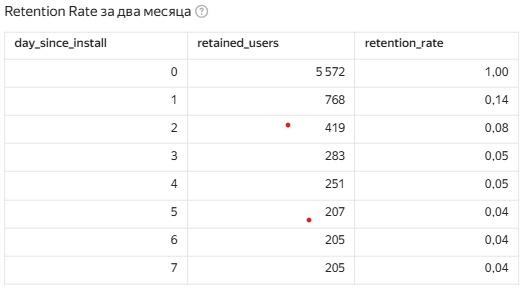

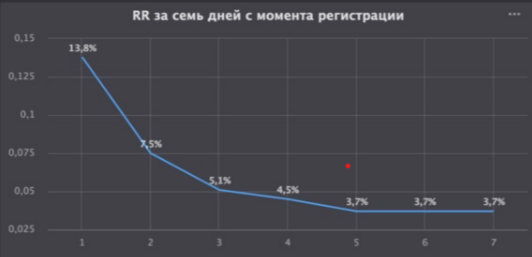

Вывод: Retention Rate в первую неделю для всех новых пользователей в городе Саранске за два рассматриваемых месяца на седьмой день активности составил 4%, при этом аналогичный процент возвращающихся клиентов можно увидеть, начиная с пятого дня. Стоит отметить, что аналогичный показатель в период с третьего по четвертый день составил 5%, что может говорить о формировании довольно устойчивой клиентской базы, начиная с третьего дня после регистрации.  
В первый день после регистрации активных клиентов осталось 14% от всех зарегистрированных, на второй день – 8%. 
Вероятно, быстрое снижение RR — типичная ситуация для подобных сервисов, но полезно сравнить показатели с рыночными бенчмарками, чтобы понять, насколько это критично.

### Задача 7. Сравнение Retention Rate по месяцам
Используя эталонный код из предыдущей задачи, пользователи будут разделены на две когорты по месяцу первого посещения продукта.

In [14]:
result = duckdb.sql("""
WITH new_users AS (
    SELECT DISTINCT
        CAST(first_date AS DATE) AS first_date,
        user_id
    FROM analytics_events
    JOIN cities ON analytics_events.city_id = cities.city_id
    WHERE CAST(first_date AS DATE) BETWEEN '2021-05-01' AND '2021-06-24'
        AND city_name = 'Саранск'
),

-- Рассчитываем активных пользователей по дате события
active_users AS (
    SELECT DISTINCT
        CAST(log_date AS DATE) AS log_date,
        user_id
    FROM analytics_events
    JOIN cities ON analytics_events.city_id = cities.city_id
    WHERE CAST(log_date AS DATE) BETWEEN '2021-05-01' AND '2021-06-30'
        AND city_name = 'Саранск'
),

-- Соединяем таблицы с новыми и активными пользователями
daily_retention AS (
    SELECT
        n.user_id,
        n.first_date,
        a.log_date - n.first_date AS day_since_install
    FROM new_users AS n
    JOIN active_users AS a ON n.user_id = a.user_id
        AND a.log_date >= n.first_date
)

SELECT
    CAST(DATE_TRUNC('month', first_date) AS DATE) AS "Месяц",
    day_since_install,
    COUNT(DISTINCT user_id) AS retained_users,
    ROUND(
        (1.0 * COUNT(DISTINCT user_id)) /
        FIRST_VALUE(COUNT(DISTINCT user_id)) OVER (
            PARTITION BY CAST(DATE_TRUNC('month', first_date) AS DATE)
            ORDER BY day_since_install
            ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
        ),
        2
    ) AS retention_rate
FROM daily_retention
WHERE day_since_install < 8
GROUP BY CAST(DATE_TRUNC('month', first_date) AS DATE), day_since_install
ORDER BY "Месяц", day_since_install
""").df()

Сводная таблица и дополнительный график RR в разрезе месяца регистрации (май, июнь 2021 года).

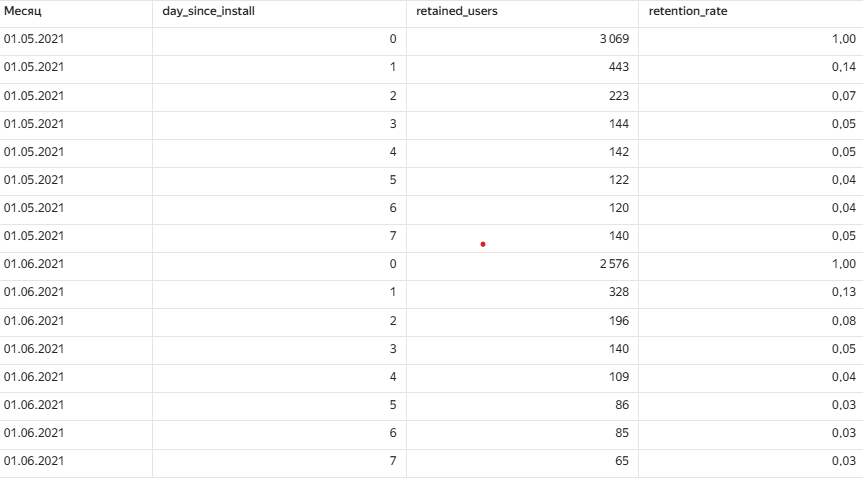

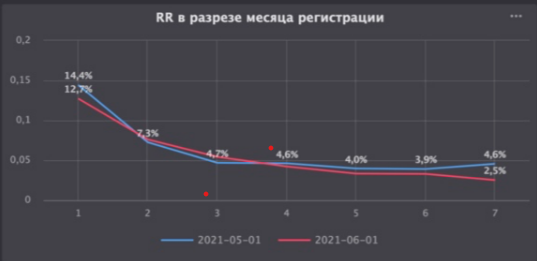

Вывод: У майской когорты Retention Rate первой недели составил 5%, а июньской — 3%, что говорит о том, что Retention Rate первой недели лучше у майской когорты. При этом на следующий день после регистрации Retention Rate у майской когорты составил 14%, у июньской – 13%. За исключением третьего дня после регистрации Retention Rate у майской и июньской когорт отличался на 1-2% (на третий день разницы в показателе возвращаемости не было, Retention Rate составил 5%).

## Общий вид дашборда по рассчитанным метрикам в Yandex DataLens

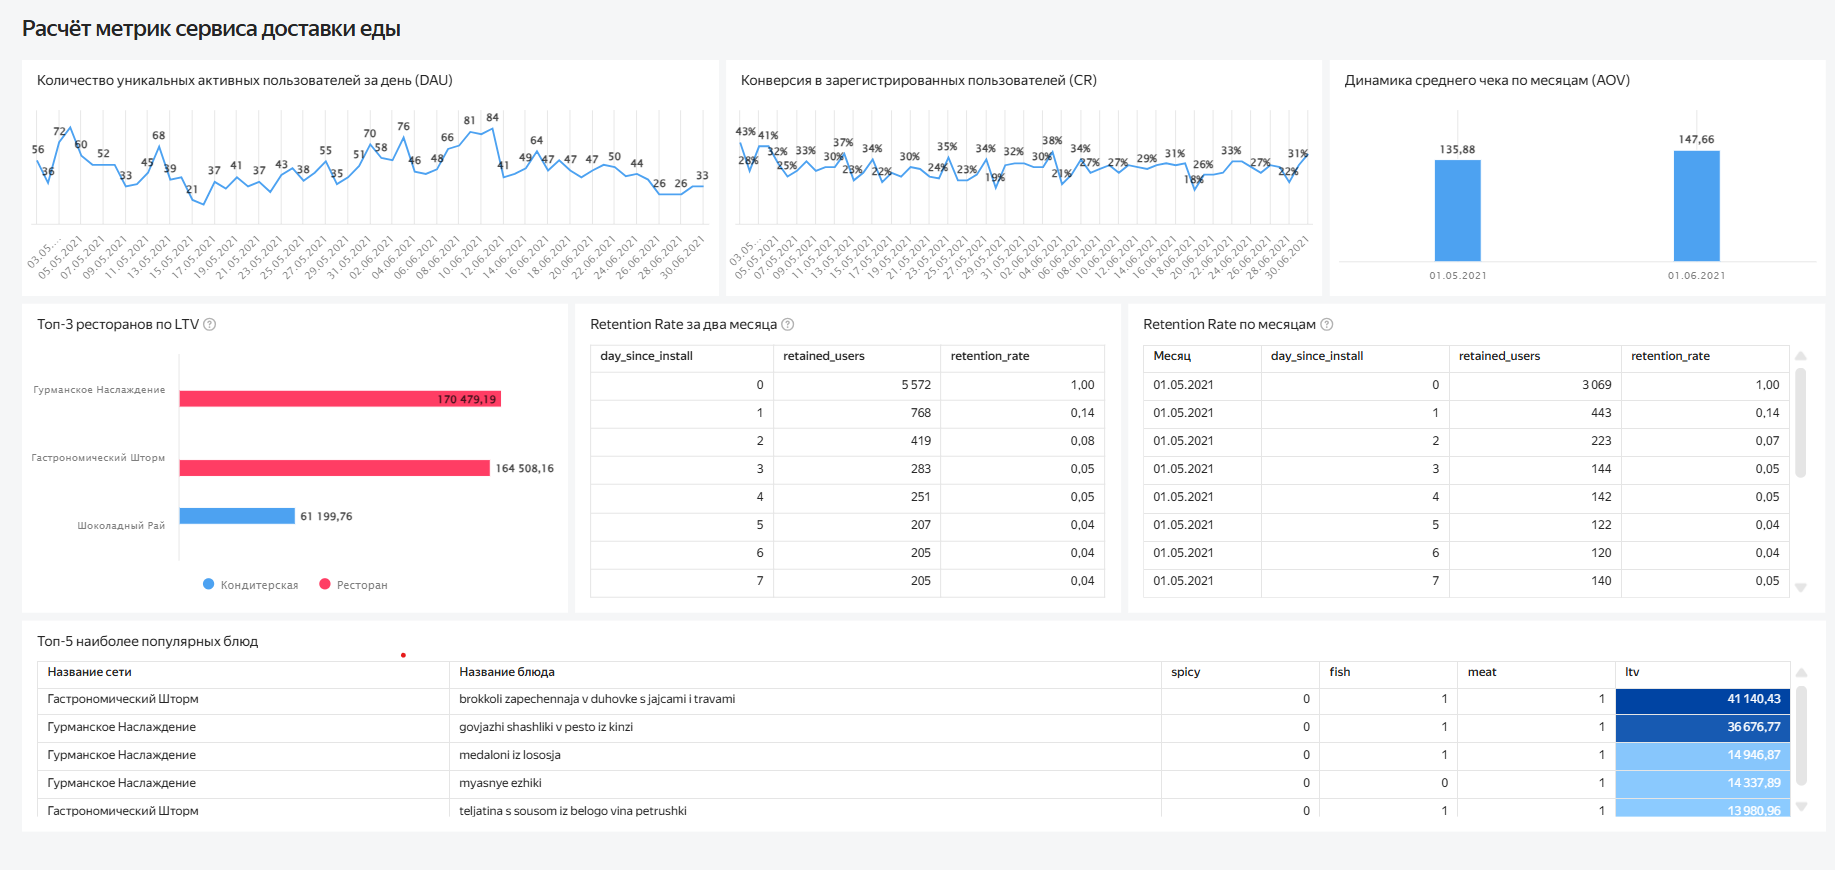

Общие выводы и рекомендации: В свете снижения количества активных пользователей за день (DAU) и довольно стабильной конверсии зарегистрированных пользователей в тех, которые начинают совершать заказы, можно рассмотреть использование маркетинговых компаний по привлечению новых пользователей (например, скидки на первый заказ для новых клиентов). 
Также стоит обратить внимание на довольно большие потери (около 86-87%) возвращаемости активных клиентов после регистрации. Возможно, процесс оформления заказа для клиента не совсем понятен/удобен. С этой целью рекомендуется провести анализ этапов выполнения заказа с точки зрения клиента (продуктовая воронка). 